# Music Genre Classifier — Training Notebook
Run this once to train and save all models to `models/`.
The Streamlit app loads from there — no training happens in the app.

In [2]:
import sys
sys.path.append('..')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

from src.config import (
    FEATURES_30_SEC, IMG_DIR,
    RF_PATH, SCALER_PATH, LE_PATH, CNN_PATH,
    TEST_SIZE, RANDOM_STATE, N_ESTIMATORS,
    IMG_SIZE, BATCH_SIZE, EPOCHS_FROZEN, EPOCHS_FINETUNE, FINETUNE_LR
)

os.makedirs('../models', exist_ok=True)
print('Setup complete')

Setup complete


## 1. Load & Preprocess Tabular Data

In [3]:
df = pd.read_csv(FEATURES_30_SEC)
print(f'Dataset shape: {df.shape}')
print(f'Genres: {df["label"].unique()}')
df.head()

Dataset shape: (1000, 60)
Genres: ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


In [4]:
X = df.drop(columns=['filename', 'label']).values
y = df['label'].values

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f'Train: {len(X_train)} | Test: {len(X_test)}')

# Save scaler and label encoder immediately
joblib.dump(scaler, SCALER_PATH)
joblib.dump(le, LE_PATH)
print('Scaler and LabelEncoder saved.')

Train: 800 | Test: 200
Scaler and LabelEncoder saved.


## 2. Random Forest

In [5]:
rf = RandomForestClassifier(n_estimators=N_ESTIMATORS, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
tabular_acc = np.mean(y_pred == y_test)

print('=== Random Forest Results ===')
print(classification_report(y_test, y_pred, target_names=le.classes_))

joblib.dump(rf, RF_PATH)
print(f'Random Forest saved to {RF_PATH}')

=== Random Forest Results ===
              precision    recall  f1-score   support

       blues       0.65      0.85      0.74        20
   classical       1.00      1.00      1.00        13
     country       0.76      0.59      0.67        27
       disco       0.83      0.71      0.77        21
      hiphop       0.59      0.87      0.70        15
        jazz       0.91      0.95      0.93        22
       metal       0.86      0.96      0.91        25
         pop       0.82      0.69      0.75        13
      reggae       0.70      0.61      0.65        23
        rock       0.61      0.52      0.56        21

    accuracy                           0.77       200
   macro avg       0.77      0.78      0.77       200
weighted avg       0.77      0.77      0.76       200

Random Forest saved to ../models/random_forest.pkl


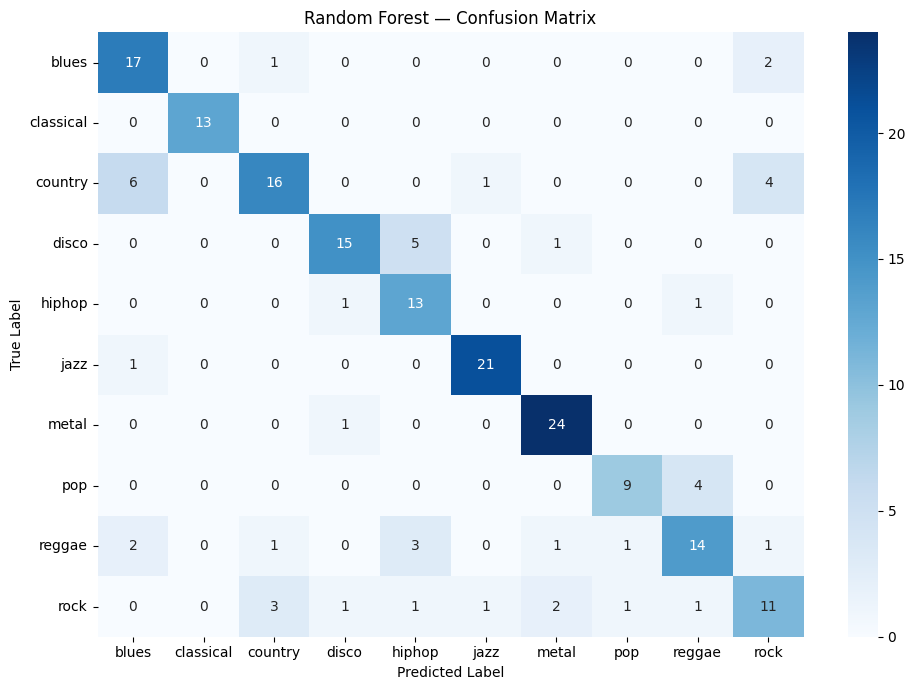

In [6]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../models/rf_confusion_matrix.png', dpi=150)
plt.show()

## 3. CNN (ResNet50 + Fine-tuning)

In [7]:
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    IMG_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=RANDOM_STATE
)
val_gen = datagen.flow_from_directory(
    IMG_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=RANDOM_STATE
)

print(f'Classes: {list(train_gen.class_indices.keys())}')
print(f'Train images: {train_gen.samples} | Val images: {val_gen.samples}')

Found 800 images belonging to 10 classes.
Found 199 images belonging to 10 classes.
Classes: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Train images: 800 | Val images: 199


In [8]:
# --- Build model ---
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
preds = Dense(len(train_gen.class_indices), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=preds)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print('Phase 1: training custom head (base frozen)...')
h1 = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS_FROZEN)

Phase 1: training custom head (base frozen)...
Epoch 1/15


/Users/batman/Library/Python/3.9/lib/python/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


25/25 ━━━━━━━━━━━━━━━━━━━━ 27s 887ms/step - accuracy: 0.0841 - loss: 2.7435 - val_accuracy: 0.1357 - val_loss: 2.2912
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 808ms/step - accuracy: 0.1036 - loss: 2.3243 - val_accuracy: 0.1357 - val_loss: 2.2810
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 820ms/step - accuracy: 0.1053 - loss: 2.3033 - val_accuracy: 0.1005 - val_loss: 2.2765
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 791ms/step - accuracy: 0.1653 - loss: 2.2798 - val_accuracy: 0.1005 - val_loss: 2.2769
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 776ms/step - accuracy: 0.1186 - loss: 2.2922 - val_accuracy: 0.1407 - val_loss: 2.2652
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 775ms/step - accuracy: 0.1395 - loss: 2.2803 - val_accuracy: 0.1005 - val_loss: 2.2645
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 768ms/step - accuracy: 0.1264 - loss: 2.2783 - val_accuracy: 0.1055 - val_loss: 2.2534
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 777ms/step - accuracy: 0.1345 - loss: 2.2723 - val_accuracy: 0.130

In [9]:
# --- Phase 2: fine-tune last 20 layers ---
print('Phase 2: unfreezing last 20 layers for fine-tuning...')
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(FINETUNE_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

h2 = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS_FINETUNE)

model.save(CNN_PATH)
print(f'CNN saved to {CNN_PATH}')

Phase 2: unfreezing last 20 layers for fine-tuning...
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 30s 983ms/step - accuracy: 0.1609 - loss: 2.2998 - val_accuracy: 0.2362 - val_loss: 2.1630
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.2110 - loss: 2.1030 - val_accuracy: 0.1859 - val_loss: 2.2418
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.2509 - loss: 2.0575 - val_accuracy: 0.1055 - val_loss: 2.3021
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 25s 984ms/step - accuracy: 0.3029 - loss: 1.9698 - val_accuracy: 0.1005 - val_loss: 2.3204
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 25s 987ms/step - accuracy: 0.3288 - loss: 1.9197 - val_accuracy: 0.1005 - val_loss: 2.3274
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 24s 974ms/step - accuracy: 0.3230 - loss: 1.8909 - val_accuracy: 0.1005 - val_loss: 2.3340
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.3849 - loss: 1.8033 - val_accuracy: 0.1005 - val_loss: 2.3341
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - 

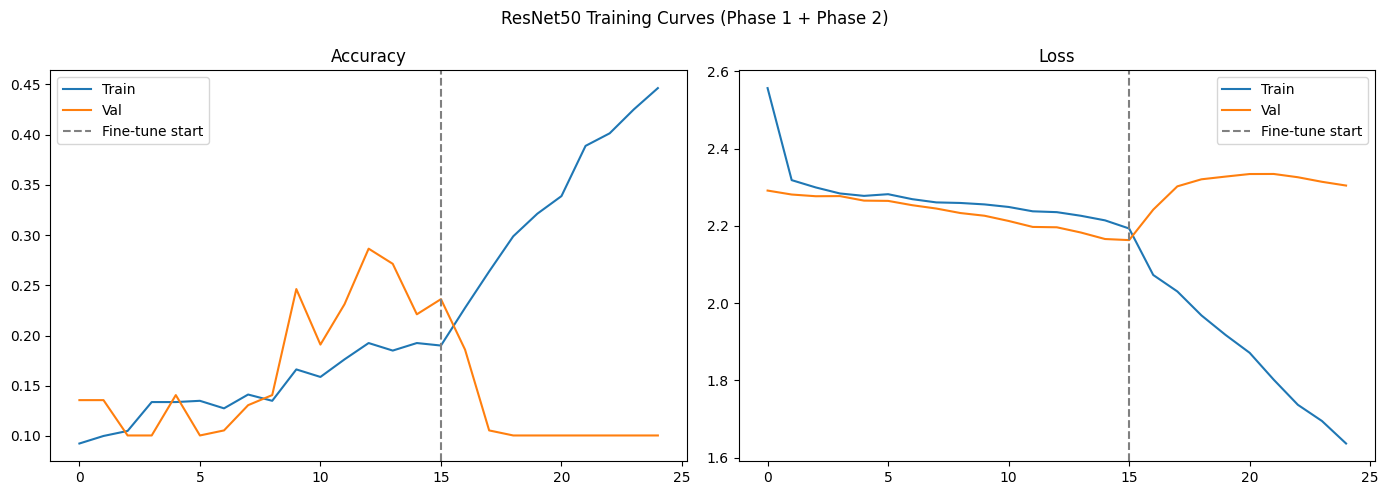

CNN final val accuracy: 0.10


In [10]:
# --- Plot combined training curves ---
acc    = h1.history['accuracy']    + h2.history['accuracy']
val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
loss   = h1.history['loss']        + h2.history['loss']
val_loss = h1.history['val_loss']  + h2.history['val_loss']

epochs_range = range(len(acc))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, acc, label='Train')
axes[0].plot(epochs_range, val_acc, label='Val')
axes[0].axvline(x=EPOCHS_FROZEN, color='gray', linestyle='--', label='Fine-tune start')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(epochs_range, loss, label='Train')
axes[1].plot(epochs_range, val_loss, label='Val')
axes[1].axvline(x=EPOCHS_FROZEN, color='gray', linestyle='--', label='Fine-tune start')
axes[1].set_title('Loss')
axes[1].legend()

plt.suptitle('ResNet50 Training Curves (Phase 1 + Phase 2)')
plt.tight_layout()
plt.savefig('../models/cnn_training_curves.png', dpi=150)
plt.show()

cnn_acc = val_acc[-1]
print(f'CNN final val accuracy: {cnn_acc:.2f}')

## 4. Compare Models

In [11]:
print('\n=== Final Comparison ===')
print(f'  Random Forest (tabular features) : {tabular_acc:.2f}')
print(f'  CNN (ResNet50 spectrograms)       : {cnn_acc:.2f}')

if cnn_acc > tabular_acc:
    print('\n  CNN outperformed the tabular approach.')
else:
    print('\n  Random Forest outperformed CNN — tabular features are strong for this dataset size.')

print('\nAll models saved to models/. You can now run app.py.')


=== Final Comparison ===
  Random Forest (tabular features) : 0.77
  CNN (ResNet50 spectrograms)       : 0.10

  Random Forest outperformed CNN — tabular features are strong for this dataset size.

All models saved to models/. You can now run app.py.
